# Static susceptibility χ(q; G, G') — rhombohedral multilayer graphene

This notebook demonstrates `calculate_chi_q`, which computes the static Lindhard function

$$
\chi^{\tau\tau'}(\mathbf{q}; \mathbf{G}, \mathbf{G}') = \frac{1}{N_k}
\sum_{\mathbf{k},n,m} M^{\tau\tau'}_{nm}(\mathbf{k},\mathbf{q};\mathbf{G})\,
W^{\tau\tau'}_{\mathbf{k},nm}\,
\bigl[M^{\tau\tau'}_{nm}(\mathbf{k},\mathbf{q};\mathbf{G}')\bigr]^*
$$

with valley pseudospin $\tau,\tau'\in\{K,K'\}$ kept explicit, and moiré reciprocal-lattice
vectors $\mathbf{G},\mathbf{G}'$ resolved individually.

**Form factor** (G-shift in the plane-wave basis):
$$M^{\tau\tau'}_{nm}(\mathbf{k},\mathbf{q};\mathbf{G}) = \sum_\alpha u^{*}_{\mathbf{k}+\mathbf{q},m,\tau'}[\alpha]\,u_{\mathbf{k},n,\tau}[\alpha+\mathbf{G}]$$

**Lindhard weight** (static, $\omega=0$):
$$W_{nm} = \frac{f(E^\tau_{\mathbf{k},n}) - f(E^{\tau'}_{\mathbf{k}+\mathbf{q},m})}{E^{\tau'}_{\mathbf{k}+\mathbf{q},m} - E^\tau_{\mathbf{k},n}}, \qquad |\Delta E|\to 0:\; W = \beta f(1-f)$$

The Fortran kernel (`calculate_chi.f90`) is parallelised with OpenMP and called via f2py.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from lrpa.models.rhombohedral_multilayer import RhombohedralMultilayer
from lrpa.chemical_potential import calculate_mu

## 1. Build the model

In [4]:
# Twisted bilayer graphene at the magic angle
model = RhombohedralMultilayer(nlayer=2, theta=1.08, Qcut=3)

N = 12          # k-mesh: N×N points in the mBZ
T = 10.0        # temperature [K]
occ = 0.0       # filling: 0 = charge neutrality point

model.init_mesh(N=N)
model.calculate_bandstructure()
calculate_mu(model, occ=occ, T=T)

print(f"Chemical potential μ = {model.mu*1000:.3f} meV")
print(f"Inverse temperature β = {model.beta:.1f} eV⁻¹")
print(f"Basis size Ndim = {model.Ndim}  (Nqvec={model.Nqvec}, nlayer={model.nlayer})")
print(f"k-points: {model.nk}  ({N}×{N} mesh)")

Chemical potential μ = -0.000 meV
Inverse temperature β = 1160.5 eV⁻¹
Basis size Ndim = 196  (Nqvec=49, nlayer=2)
k-points: 144  (12×12 mesh)


## 2. Band structure along Γ → M → K → Γ

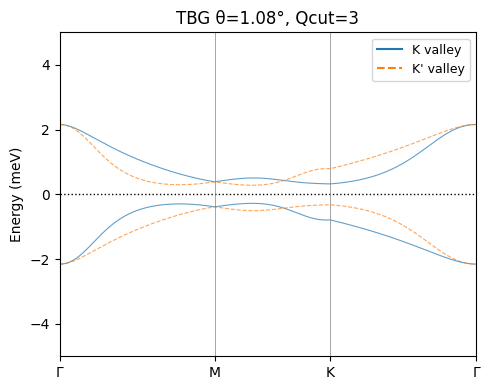

In [5]:
# High-symmetry path in fractional mBZ coordinates
npath = 200
G = np.array([0.0, 0.0])
M = np.array([0.5, 0.0])
K = np.array([1/3, 1/3])

seg1 = np.linspace(G, M, npath, endpoint=False)
seg2 = np.linspace(M, K, npath, endpoint=False)
seg3 = np.linspace(K, G, npath, endpoint=True)
kpath = np.vstack([seg1, seg2, seg3])  # (3*npath, 2)

# Evaluate Hamiltonian along path for both valleys
e_path = np.zeros((2, len(kpath), model.Ndim))
for t, tau in enumerate([-1, +1]):
    for ki, k in enumerate(kpath):
        H = model.hamiltonian(k, valley=tau)
        e_path[t, ki] = np.linalg.eigvalsh(H)

# x-axis: accumulated path length
dk = np.linalg.norm(np.diff(kpath, axis=0), axis=1)
x = np.concatenate([[0], np.cumsum(dk)])
xticks = [x[0], x[npath], x[2*npath], x[-1]]
xlabels = ['Γ', 'M', 'K', 'Γ']

fig, ax = plt.subplots(figsize=(5, 4))
e_ref = (e_path * 1000)  # eV → meV
for n in range(model.Ndim):
    ax.plot(x, e_ref[0, :, n], 'C0', lw=0.8, alpha=0.7)
    ax.plot(x, e_ref[1, :, n], 'C1', lw=0.8, alpha=0.7, ls='--')
ax.axhline(model.mu * 1000, color='k', ls=':', lw=1, label='μ')
ax.set_xticks(xticks, xlabels)
for xt in xticks[1:-1]:
    ax.axvline(xt, color='gray', lw=0.5)
ax.set_ylabel('Energy (meV)')
ax.set_xlim(x[0], x[-1])
ax.set_ylim(-5, 5)
ax.legend(handles=[
    plt.Line2D([], [], color='C0', label='K valley'),
    plt.Line2D([], [], color='C1', ls='--', label="K' valley"),
], fontsize=9)
ax.set_title(f'TBG θ={model.theta}°, Qcut={model.Qcut}')
plt.tight_layout()
plt.show()

## 3. Consistency check: χ(q=0, G=G'=0) vs χ_ph

At **q = 0** the G = 0 form factor is the full orbital overlap, so the diagonal
element `chi_q[τ, τ', G₀, G₀]` must reproduce `chi_ph[τ, τ', τ', τ]` from the
simpler spinless particle-hole bubble.

In [ ]:
model.calculate_chi_ph_spinless()
chi_ph = model.chi_ph.copy()

chi_q0 = model.calculate_chi_q([0.0, 0.0])   # (2, 2, NG, NG)

G0 = model._qvec_to_idx[(0, 0)]   # index of G = (0,0) in the truncated basis
print(f"G₀ index = {G0}  (out of NG={model.Nqvec} G-vectors)\n")

print("chi_ph vs chi_q[G0,G0]:")
for tau in range(2):
    for taup in range(2):
        ref = chi_ph[tau, taup, taup, tau]
        got = chi_q0[tau, taup, G0, G0].real
        print(f"  τ={tau} τ'={taup}:  chi_ph = {ref:.6e}   chi_q = {got:.6e}   diff = {abs(ref-got):.1e}")

## 4. The full χ(q=0) matrix — heatmap

Each panel shows one of the four (τ, τ') valley blocks as an NG × NG matrix.
The intra-valley blocks (τ = τ') are positive semidefinite and real;
off-diagonal blocks are generally complex.

In [ ]:
NG = model.Nqvec

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
valley_labels = ['K', "K'"]

vmax = np.abs(chi_q0).max()

for tau in range(2):
    for taup in range(2):
        ax = axes[tau, taup]
        data = chi_q0[tau, taup].real
        im = ax.imshow(data, origin='lower',
                       cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                       interpolation='nearest')
        ax.set_title(f"Re χ[{valley_labels[tau]},{valley_labels[taup]}]", fontsize=11)
        ax.set_xlabel('G\' index')
        ax.set_ylabel('G index')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Static χ(q=0; G, G\') — real part  [eV⁻¹]', fontsize=13)
plt.tight_layout()
plt.show()

## 5. q-dependent charge susceptibility χ_c(q)

The **charge susceptibility** is the intra-valley sum at G = G' = 0:

$$\chi_c(\mathbf{q}) = \sum_\tau \chi^{\tau\tau}(\mathbf{q}; \mathbf{G}_0, \mathbf{G}_0)$$

We scan **q** along the high-symmetry path Γ → M → K → Γ.

In [ ]:
# Coarser path for the q-scan (chi_q is O(N²) per q-point)
nq = 30
qseg1 = np.linspace(G, M, nq, endpoint=False)
qseg2 = np.linspace(M, K, nq, endpoint=False)
qseg3 = np.linspace(K, G, nq, endpoint=True)
qpath = np.vstack([qseg1, qseg2, qseg3])

dq = np.linalg.norm(np.diff(qpath, axis=0), axis=1)
xq = np.concatenate([[0], np.cumsum(dq)])
xticks_q = [xq[0], xq[nq], xq[2*nq], xq[-1]]

chi_c = np.zeros(len(qpath))

for qi, q in enumerate(qpath):
    chi = model.calculate_chi_q(q)
    chi_c[qi] = (chi[0, 0, G0, G0] + chi[1, 1, G0, G0]).real

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(xq, chi_c * 1000, 'C0-o', ms=3, lw=1.5)  # convert eV⁻¹ → meV⁻¹
ax.set_xticks(xticks_q, ['Γ', 'M', 'K', 'Γ'])
for xt in xticks_q[1:-1]:
    ax.axvline(xt, color='gray', lw=0.5)
ax.set_ylabel('χ_c(q, G=0)  [meV⁻¹]')
ax.set_title(f'Charge susceptibility — TBG θ={model.theta}°, T={T} K, n={occ}')
ax.set_xlim(xq[0], xq[-1])
plt.tight_layout()
plt.show()

## 6. Temperature dependence at q = 0

At charge neutrality the flat-band DOS produces a strong temperature dependence.

In [ ]:
temps = [5, 10, 20, 50, 100]   # K

fig, ax = plt.subplots(figsize=(5, 3.5))

for T_val in temps:
    calculate_mu(model, occ=occ, T=T_val)
    chi = model.calculate_chi_q([0.0, 0.0])
    chi_total = (chi[0, 0, G0, G0] + chi[1, 1, G0, G0]).real * 1000   # meV⁻¹
    ax.scatter(T_val, chi_total, zorder=3)

ax.set_xlabel('Temperature T [K]')
ax.set_ylabel('χ_c(q=0, G=0)  [meV⁻¹]')
ax.set_title('T-dependence of charge susceptibility at Γ')
plt.tight_layout()
plt.show()

# Restore to T=10 K for subsequent cells
calculate_mu(model, occ=occ, T=10.0)

## 7. Doping dependence

Scan filling from the hole side (−2 per moiré unit cell) to the electron side (+2).
The van-Hove singularity shows up as a peak in χ_c.

In [ ]:
fillings = np.linspace(-1.5, 1.5, 25)   # in units of 10¹² cm⁻²
chi_vs_n = np.zeros(len(fillings))

for i, n in enumerate(fillings):
    calculate_mu(model, occ=n, T=10.0)
    chi = model.calculate_chi_q([0.0, 0.0])
    chi_vs_n[i] = (chi[0, 0, G0, G0] + chi[1, 1, G0, G0]).real * 1000

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(fillings, chi_vs_n, 'C2-o', ms=4)
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('Filling n  [10¹² cm⁻²]')
ax.set_ylabel('χ_c(q=0, G=0)  [meV⁻¹]')
ax.set_title(f'Doping scan — TBG θ={model.theta}°, T=10 K')
plt.tight_layout()
plt.show()

# Restore neutral filling
calculate_mu(model, occ=0.0, T=10.0)

## 8. Inter-valley vs intra-valley blocks

Split the total G = G' = 0 susceptibility into intra-valley (K→K, K'→K') and
inter-valley (K→K', K'→K) contributions along the BZ path.

In [ ]:
intra = np.zeros(len(qpath))
inter = np.zeros(len(qpath), dtype=complex)

for qi, q in enumerate(qpath):
    chi = model.calculate_chi_q(q)
    intra[qi] = (chi[0, 0, G0, G0] + chi[1, 1, G0, G0]).real
    inter[qi] =  chi[0, 1, G0, G0] + chi[1, 0, G0, G0]

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(xq, intra * 1000,          'C0-',  lw=1.5, label='intra-valley (K+K\'')
ax.plot(xq, inter.real * 1000,     'C1--', lw=1.5, label='inter-valley Re')
ax.plot(xq, inter.imag * 1000,     'C1:',  lw=1.0, label='inter-valley Im')
ax.set_xticks(xticks_q, ['Γ', 'M', 'K', 'Γ'])
for xt in xticks_q[1:-1]:
    ax.axvline(xt, color='gray', lw=0.5)
ax.set_ylabel('χ(q, G=G\'=0)  [meV⁻¹]')
ax.set_title('Intra- vs inter-valley susceptibility')
ax.legend(fontsize=9)
ax.set_xlim(xq[0], xq[-1])
plt.tight_layout()
plt.show()

## 9. χ(q, G, G') on the full 2D mBZ

Compute χ_c(q) on the entire N × N mesh and plot the result as a 2D heatmap.
This uses the same k-grid already computed during `calculate_bandstructure`.

In [ ]:
chi_map = np.zeros((N, N))

# q runs over the same fractional grid as the k-mesh
qn = np.arange(N) / N

for iqy in range(N):
    for iqx in range(N):
        q = [qn[iqx], qn[iqy]]
        chi = model.calculate_chi_q(q)
        chi_map[iqy, iqx] = (chi[0, 0, G0, G0] + chi[1, 1, G0, G0]).real

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(chi_map * 1000, origin='lower', cmap='inferno',
               extent=[0, 1, 0, 1], aspect='equal')
plt.colorbar(im, ax=ax, label='χ_c(q, G=0)  [meV⁻¹]')
ax.set_xlabel('q_x  [mBZ frac.]')
ax.set_ylabel('q_y  [mBZ frac.]')
ax.set_title(f'Charge susceptibility — 2D mBZ\n(TBG θ={model.theta}°, T=10 K, n=0)')
plt.tight_layout()
plt.show()